# Bulk lncRNA Validation

High-level validation statistics for all lncRNAs in the dataset.

Checks:
- How many genes have island predictions
- How many predictions intersect GENCODE mouse annotation
- Distribution of island counts, MMD values, overlap percentages
- Overall prediction quality metrics

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyrion.core import TranscriptsCollection
from pyrion.io import read_bed12_file

# Directories
PIPELINE_DIR = Path("../quick_test")
ANNOTATION_DIR = Path("../input_data/mm39_annotation_validation")

# Matplotlib settings
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## 1. Load Data

In [ ]:
# Load island alignment results
results = pd.read_csv(
    PIPELINE_DIR / "island_alignment_results.tsv",
    sep="\t"
)

# Convert MMD to float
results['diag_mmd'] = results['diag_mmd'].astype(float)

# Load BED files
query_bed = read_bed12_file(
    str(PIPELINE_DIR / "query_annotation" / "lncRNA_islands.bed")
)

# Load annotation
annotation = read_bed12_file(
    str(ANNOTATION_DIR / "mm39_quick_test_transcripts.bed")
)

print(f"Island results: {len(results)} total")
print(f"Query BED: {len(query_bed)} entries")
print(f"Annotation: {len(annotation):,} transcripts")
print(f"\nUnique genes: {results['gene_id'].nunique()}")
print(f"Anchor islands: {(results['type'] == 'anchor').sum()}")
print(f"Fill islands: {(results['type'] == 'fill').sum()}")

Island results: 295 total
Query BED: 67 entries
Annotation: 35,597 transcripts

Unique genes: 67
Anchor islands: 295
Fill islands: 0


## 2. Per-Gene Summary Statistics

In [3]:
# Aggregate by gene
gene_stats = results.groupby('gene_id').agg({
    'query_island': 'count',  # total islands
    'type': lambda x: (x == 'anchor').sum(),  # anchor count
    'query_len': 'sum',  # total predicted bp
    'diag_mmd': ['mean', 'median', 'std'],
    'query_chrom': 'first',
}).reset_index()

gene_stats.columns = [
    'gene_id', 'n_islands', 'n_anchors', 'total_bp',
    'mean_mmd', 'median_mmd', 'std_mmd', 'query_chrom'
]

# Add fill count
fill_counts = results[results['type'] == 'fill'].groupby('gene_id').size()
gene_stats['n_fills'] = gene_stats['gene_id'].map(fill_counts).fillna(0).astype(int)

print(f"Summary for {len(gene_stats)} genes:")
print(gene_stats.describe())

Summary for 67 genes:
       n_islands  n_anchors      total_bp   mean_mmd  median_mmd    std_mmd  \
count  67.000000  67.000000     67.000000  67.000000   67.000000  41.000000   
mean    4.402985   4.402985    735.402985   0.047195    0.046195   0.027581   
std    10.347097  10.347097   1559.487290   0.036340    0.037536   0.015295   
min     1.000000   1.000000     72.000000   0.000000    0.000000   0.000000   
25%     1.000000   1.000000    176.000000   0.021470    0.019300   0.017607   
50%     2.000000   2.000000    344.000000   0.042080    0.038450   0.025731   
75%     3.000000   3.000000    588.000000   0.062754    0.063800   0.033713   
max    69.000000  69.000000  10632.000000   0.202100    0.202100   0.080257   

       n_fills  
count     67.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  


## 3. Overlap with Mouse Annotation

In [4]:
def compute_overlap_stats(gene_id):
    """Compute overlap statistics for a gene."""
    from pyrion.core.intervals import GenomicInterval
    
    # Get query transcript for this gene
    q_transcripts = [t for t in query_bed if t.id.startswith(gene_id)]
    if not q_transcripts:
        return None
    
    # Merge all exons for this gene
    all_blocks = []
    chrom = None
    for t in q_transcripts:
        chrom = t.chrom
        # Convert numpy arrays to tuples for sorting
        all_blocks.extend([(int(s), int(e)) for s, e in t.blocks])
    
    if not all_blocks:
        return None
    
    # Merge overlapping blocks
    merged = []
    for block in sorted(all_blocks):
        if merged and block[0] <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], block[1]))
        else:
            merged.append(block)
    
    total_bp = sum(e - s for s, e in merged)
    
    # Find annotation transcripts in the same region
    span_start = min(s for s, e in merged)
    span_end = max(e for s, e in merged)
    
    # Create GenomicInterval and get transcripts
    query_interval = GenomicInterval(chrom=chrom, start=span_start, end=span_end)
    anno_hits_collection = annotation.get_transcripts_in_interval(query_interval, include_partial=True)
    anno_hits = list(anno_hits_collection)
    
    if not anno_hits:
        return {
            'exonic_bp': total_bp,
            'n_anno_transcripts': 0,
            'n_anno_overlapping': 0,
            'overlap_bp': 0,
            'overlap_pct': 0.0,
        }
    
    # Check overlap
    overlapping = []
    max_overlap_bp = 0
    
    for anno_t in anno_hits:
        overlap_bp = 0
        for q_s, q_e in merged:
            # Convert annotation blocks to integers
            for block in anno_t.blocks:
                a_s, a_e = int(block[0]), int(block[1])
                overlap_start = max(q_s, a_s)
                overlap_end = min(q_e, a_e)
                if overlap_start < overlap_end:
                    overlap_bp += overlap_end - overlap_start
        
        if overlap_bp > 0:
            overlapping.append(anno_t.id)
            max_overlap_bp = max(max_overlap_bp, overlap_bp)
    
    return {
        'exonic_bp': total_bp,
        'n_anno_transcripts': len(anno_hits),
        'n_anno_overlapping': len(overlapping),
        'overlap_bp': max_overlap_bp,
        'overlap_pct': 100 * max_overlap_bp / total_bp if total_bp > 0 else 0.0,
    }

# Compute overlap for all genes
print("Computing annotation overlaps...")
overlap_stats = []
for gene_id in gene_stats['gene_id']:
    stats = compute_overlap_stats(gene_id)
    if stats:
        stats['gene_id'] = gene_id
        overlap_stats.append(stats)

overlap_df = pd.DataFrame(overlap_stats)

# Merge with gene stats
gene_stats = gene_stats.merge(overlap_df, on='gene_id', how='left')

print(f"\nOverlap statistics computed for {len(overlap_df)} genes")
print(f"Genes with annotation overlap: {(gene_stats['n_anno_overlapping'] > 0).sum()}")
print(f"Genes with >50% overlap: {(gene_stats['overlap_pct'] > 50).sum()}")
print(f"Genes with 100% overlap: {(gene_stats['overlap_pct'] == 100).sum()}")

Computing annotation overlaps...

Overlap statistics computed for 67 genes
Genes with annotation overlap: 23
Genes with >50% overlap: 17
Genes with 100% overlap: 12


## 4. Overview Statistics

In [5]:
# Overall summary
print("=" * 60)
print("OVERALL VALIDATION SUMMARY")
print("=" * 60)

total_genes = len(gene_stats)
genes_with_overlap = (gene_stats['n_anno_overlapping'] > 0).sum()
genes_high_quality = (gene_stats['overlap_pct'] >= 50).sum()
genes_perfect = (gene_stats['overlap_pct'] == 100).sum()

print(f"\nTotal genes with predictions: {total_genes}")
print(f"Genes with annotation overlap: {genes_with_overlap} ({100*genes_with_overlap/total_genes:.1f}%)")
print(f"Genes with ≥50% overlap: {genes_high_quality} ({100*genes_high_quality/total_genes:.1f}%)")
print(f"Genes with 100% overlap: {genes_perfect} ({100*genes_perfect/total_genes:.1f}%)")

print(f"\nIsland statistics:")
print(f"  Total islands: {results.shape[0]}")
print(f"  Anchors: {(results['type'] == 'anchor').sum()}")
print(f"  Fills: {(results['type'] == 'fill').sum()}")
print(f"  Mean islands per gene: {gene_stats['n_islands'].mean():.1f}")
print(f"  Median islands per gene: {gene_stats['n_islands'].median():.0f}")

print(f"\nMMD quality:")
print(f"  Mean MMD: {results['diag_mmd'].mean():.4f}")
print(f"  Median MMD: {results['diag_mmd'].median():.4f}")
print(f"  Islands with MMD < 0.05: {(results['diag_mmd'] < 0.05).sum()} ({100*(results['diag_mmd'] < 0.05).sum()/len(results):.1f}%)")
print(f"  Islands with MMD < 0.1: {(results['diag_mmd'] < 0.1).sum()} ({100*(results['diag_mmd'] < 0.1).sum()/len(results):.1f}%)")

print(f"\nPredicted sequence:")
print(f"  Total bp predicted: {gene_stats['total_bp'].sum():,}")
print(f"  Mean bp per gene: {gene_stats['total_bp'].mean():.0f}")
print(f"  Median bp per gene: {gene_stats['total_bp'].median():.0f}")

OVERALL VALIDATION SUMMARY

Total genes with predictions: 67
Genes with annotation overlap: 23 (34.3%)
Genes with ≥50% overlap: 17 (25.4%)
Genes with 100% overlap: 12 (17.9%)

Island statistics:
  Total islands: 295
  Anchors: 295
  Fills: 0
  Mean islands per gene: 4.4
  Median islands per gene: 2

MMD quality:
  Mean MMD: 0.0425
  Median MMD: 0.0348
  Islands with MMD < 0.05: 189 (64.1%)
  Islands with MMD < 0.1: 280 (94.9%)

Predicted sequence:
  Total bp predicted: 49,272
  Mean bp per gene: 735
  Median bp per gene: 344


## 5. Distribution Plots

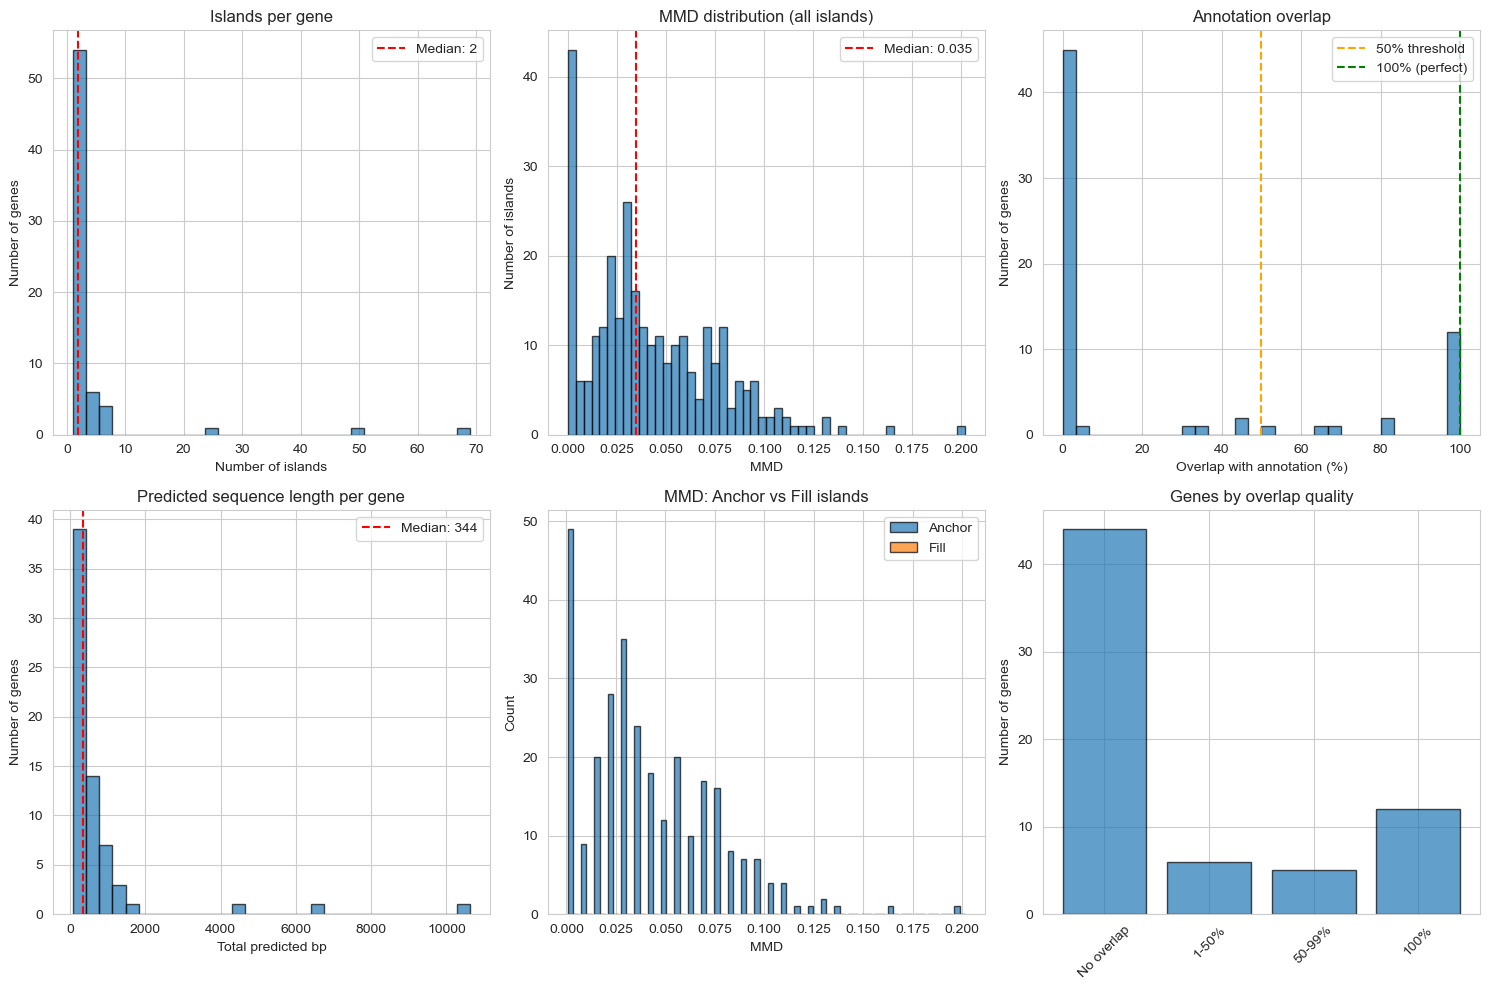

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Islands per gene
axes[0, 0].hist(gene_stats['n_islands'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of islands')
axes[0, 0].set_ylabel('Number of genes')
axes[0, 0].set_title('Islands per gene')
axes[0, 0].axvline(gene_stats['n_islands'].median(), color='red', linestyle='--', 
                   label=f'Median: {gene_stats["n_islands"].median():.0f}')
axes[0, 0].legend()

# 2. MMD distribution
axes[0, 1].hist(results['diag_mmd'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('MMD')
axes[0, 1].set_ylabel('Number of islands')
axes[0, 1].set_title('MMD distribution (all islands)')
axes[0, 1].axvline(results['diag_mmd'].median(), color='red', linestyle='--',
                   label=f'Median: {results["diag_mmd"].median():.3f}')
axes[0, 1].legend()

# 3. Overlap percentage
axes[0, 2].hist(gene_stats['overlap_pct'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Overlap with annotation (%)')
axes[0, 2].set_ylabel('Number of genes')
axes[0, 2].set_title('Annotation overlap')
axes[0, 2].axvline(50, color='orange', linestyle='--', label='50% threshold')
axes[0, 2].axvline(100, color='green', linestyle='--', label='100% (perfect)')
axes[0, 2].legend()

# 4. Total bp per gene
axes[1, 0].hist(gene_stats['total_bp'], bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Total predicted bp')
axes[1, 0].set_ylabel('Number of genes')
axes[1, 0].set_title('Predicted sequence length per gene')
axes[1, 0].axvline(gene_stats['total_bp'].median(), color='red', linestyle='--',
                   label=f'Median: {gene_stats["total_bp"].median():.0f}')
axes[1, 0].legend()

# 5. Anchor vs Fill by MMD
anchor_mmd = results[results['type'] == 'anchor']['diag_mmd']
fill_mmd = results[results['type'] == 'fill']['diag_mmd']
axes[1, 1].hist([anchor_mmd, fill_mmd], bins=30, label=['Anchor', 'Fill'], 
                alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('MMD')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('MMD: Anchor vs Fill islands')
axes[1, 1].legend()

# 6. Genes by overlap category
categories = ['No overlap', '1-50%', '50-99%', '100%']
counts = [
    (gene_stats['overlap_pct'] == 0).sum(),
    ((gene_stats['overlap_pct'] > 0) & (gene_stats['overlap_pct'] < 50)).sum(),
    ((gene_stats['overlap_pct'] >= 50) & (gene_stats['overlap_pct'] < 100)).sum(),
    (gene_stats['overlap_pct'] == 100).sum(),
]
axes[1, 2].bar(categories, counts, edgecolor='black', alpha=0.7)
axes[1, 2].set_ylabel('Number of genes')
axes[1, 2].set_title('Genes by overlap quality')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Top/Bottom Genes by Quality

In [7]:
# Sort by overlap percentage
gene_stats_sorted = gene_stats.sort_values('overlap_pct', ascending=False)

print("Top 10 genes by annotation overlap:")
print(gene_stats_sorted[[
    'gene_id', 'n_islands', 'total_bp', 'overlap_pct', 'median_mmd'
]].head(10).to_string(index=False))

print("\n" + "="*60)
print("\nBottom 10 genes by annotation overlap:")
print(gene_stats_sorted[[
    'gene_id', 'n_islands', 'total_bp', 'overlap_pct', 'median_mmd'
]].tail(10).to_string(index=False))

Top 10 genes by annotation overlap:
          gene_id  n_islands  total_bp  overlap_pct  median_mmd
U_ENSG00000130600          3       632        100.0     0.10180
U_ENSG00000254452          1       360        100.0     0.10910
U_ENSG00000290026          1       152        100.0     0.02810
U_ENSG00000288642          5       776        100.0     0.04940
U_ENSG00000269821         69     10632        100.0     0.03050
U_ENSG00000260233          2       336        100.0     0.03845
U_ENSG00000303403          1       216        100.0     0.08150
U_ENSG00000290649          1       104        100.0     0.01440
U_ENSG00000304644          1       280        100.0     0.00000
U_ENSG00000303745          1        88        100.0     0.05470


Bottom 10 genes by annotation overlap:
          gene_id  n_islands  total_bp  overlap_pct  median_mmd
U_ENSG00000255517          2       320          0.0     0.02500
U_ENSG00000256403          1       136          0.0     0.00000
U_ENSG00000258545          

## 7. Quality Breakdown by Chromosome

In [8]:
# Group by chromosome
chrom_stats = gene_stats.groupby('query_chrom').agg({
    'gene_id': 'count',
    'n_islands': 'mean',
    'median_mmd': 'mean',
    'overlap_pct': ['mean', lambda x: (x == 100).sum()],
}).round(2)

chrom_stats.columns = ['n_genes', 'avg_islands', 'avg_mmd', 'avg_overlap_pct', 'n_perfect']

print("Statistics by chromosome:")
print(chrom_stats.to_string())

Statistics by chromosome:
             n_genes  avg_islands  avg_mmd  avg_overlap_pct  n_perfect
query_chrom                                                           
chr19             16         3.75     0.05            40.41          5
chr7              22         5.64     0.04            27.17          4
chrX              29         3.83     0.05            16.17          3


## 8. Export Summary Table

In [9]:
# Save full gene stats
output_path = Path("bulk_validation_summary.tsv")
gene_stats.to_csv(output_path, sep='\t', index=False)
print(f"Gene-level summary saved to: {output_path}")

# Create a concise summary
summary = {
    'total_genes': total_genes,
    'genes_with_overlap': genes_with_overlap,
    'genes_overlap_50pct': genes_high_quality,
    'genes_overlap_100pct': genes_perfect,
    'total_islands': len(results),
    'total_anchors': (results['type'] == 'anchor').sum(),
    'total_fills': (results['type'] == 'fill').sum(),
    'mean_mmd': results['diag_mmd'].mean(),
    'median_mmd': results['diag_mmd'].median(),
    'total_predicted_bp': gene_stats['total_bp'].sum(),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('bulk_validation_overall.tsv', sep='\t', index=False)
print("Overall summary saved to: bulk_validation_overall.tsv")

Gene-level summary saved to: bulk_validation_summary.tsv
Overall summary saved to: bulk_validation_overall.tsv
